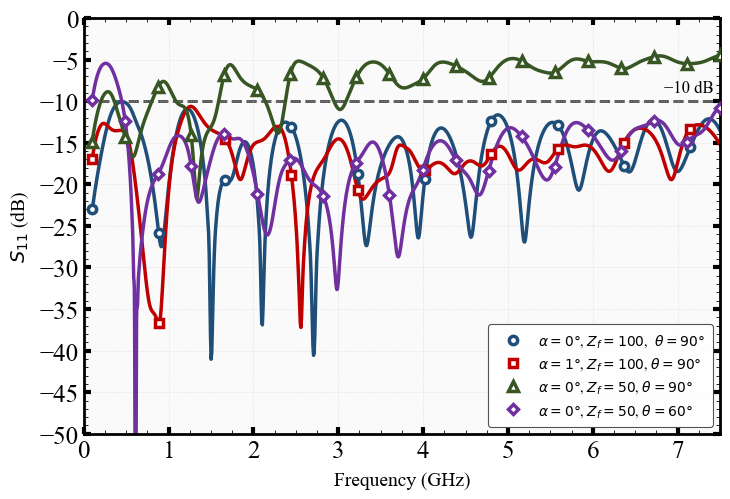

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── Publication-quality style (OriginPro-like) ───────────────────────────────
rcParams['font.family']         = 'Times New Roman'
rcParams['font.size']           = 18
rcParams['axes.linewidth']      = 2
rcParams['xtick.direction']     = 'in'
rcParams['ytick.direction']     = 'in'
rcParams['xtick.top']           = True
rcParams['ytick.right']         = True
rcParams['xtick.major.size']    = 5
rcParams['ytick.major.size']    = 5
rcParams['xtick.minor.size']    = 3
rcParams['ytick.minor.size']    = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True
rcParams['xtick.major.width']   = 3
rcParams['ytick.major.width']   = 3

# ── 1. LOAD HFSS DATA ────────────────────────────────────────────────────────
S11_1 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\S_param_alpha0_100.csv')
S11_2 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\S_param_alpha1_100.csv')
S11_3 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\S_param_alpha0_50_old.csv')
S11_4 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\S_param_alpha0_50.csv')

freq_raw_1 = S11_1['Freq [GHz]'].values * 1e9
freq_raw_2 = S11_2['Freq [GHz]'].values * 1e9
freq_raw_3 = S11_3['Freq [GHz]'].values * 1e9
freq_raw_4 = S11_4['Freq [GHz]'].values * 1e9

mag_raw_1 = S11_1['dB(S(LumpedPort1,LumpedPort1)) []'].values
mag_raw_2 = S11_2['dB(S(LumpedPort1,LumpedPort1)) []'].values
mag_raw_3 = S11_3['dB(S(LumpedPort1,LumpedPort1)) []'].values
mag_raw_4 = S11_4['dB(S(LumpedPort1,LumpedPort1)) []'].values

# ── 2. INTERPOLATE onto fine FFT grid ────────────────────────────────────────
interp_mag_1 = CubicSpline(freq_raw_1, mag_raw_1)
interp_mag_2 = CubicSpline(freq_raw_2, mag_raw_2)
interp_mag_3 = CubicSpline(freq_raw_3, mag_raw_3)
interp_mag_4 = CubicSpline(freq_raw_4, mag_raw_4)

f_freq_1 = np.linspace(freq_raw_1[0], freq_raw_1[-1], 2000)
f_freq_2 = np.linspace(freq_raw_2[0], freq_raw_2[-1], 2000)
f_freq_3 = np.linspace(freq_raw_3[0], freq_raw_3[-1], 2000)
f_freq_4 = np.linspace(freq_raw_4[0], freq_raw_4[-1], 2000)

mag_S_1 = interp_mag_1(f_freq_1)
mag_S_2 = interp_mag_2(f_freq_2)
mag_S_3 = interp_mag_3(f_freq_3)
mag_S_4 = interp_mag_4(f_freq_4)

# ── 3. MARKER POSITIONS – evenly spaced, OriginPro style ─────────────────────
n_markers = 20   # adjust to taste: more = denser markers

# ── 4. PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))

# Each dataset: (freq_array, mag_array, color, marker, marker_size, label)
datasets = [
    (f_freq_1, mag_S_1, '#1f4e79', 'o', 6.0,  r'$\alpha = 0°$, $Z_f = 100$,  $\theta = 90°$'),
    (f_freq_2, mag_S_2, '#c00000', 's', 6.0,  r'$\alpha = 1°$, $Z_f = 100$, $\theta = 90°$'),
    (f_freq_3, mag_S_3, '#375623', '^', 6.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
    (f_freq_4, mag_S_4, '#7030a0', 'D', 5.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
]

for fx, my, col, mk, ms, lbl in datasets:
    idx = np.linspace(0, len(fx) - 1, n_markers, dtype=int)

    # Solid line (no marker)
    ax.plot(fx / 1e9, my, color=col, linewidth=2.5, zorder=2)

    # Hollow markers spaced along the line (legend-only label on this handle)
    ax.plot(fx[idx] / 1e9, my[idx],
            marker=mk, color=col, markersize=ms,
            linestyle='none',
            markerfacecolor='white', markeredgewidth=2.5,
            zorder=3, label=lbl)

# ── 5. AXES ───────────────────────────────────────────────────────────────────
ax.set_xlim(0, 7.5)
# Adjust ylim to suit your data; -40 to 0 is typical for S11 in dB
ax.set_ylim(-50, 0)

ax.set_xlabel('Frequency (GHz)', fontsize=14, labelpad=6)
ax.set_ylabel(r'$S_{11}$ (dB)',  fontsize=14, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

# Standard −10 dB antenna bandwidth threshold line
ax.axhline(-10, color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=1)
ax.text(7.42, -8.9, '−10 dB', fontsize=12, color='black', ha='right')

# ── 6. LEGEND ─────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=10,
    loc='lower right',        # change to 'upper right' etc. if needed
    frameon=True,
    framealpha=0.92,
    edgecolor='#444444',
    borderpad=0.6,
    handlelength=2.4,
    handletextpad=0.6,
    labelspacing=0.45,
)
leg.get_frame().set_linewidth(0.8)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, color='#cccccc', alpha=0.8)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.8)

# ── 7. SAVE ───────────────────────────────────────────────────────────────────
plt.savefig('S11_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

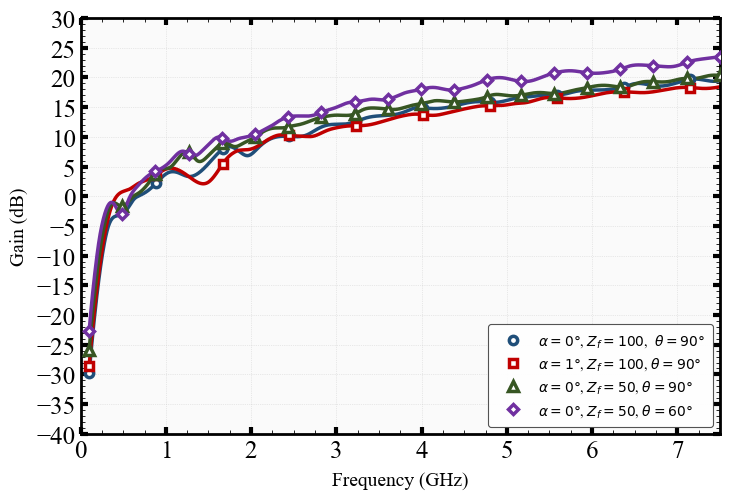

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── Publication-quality style (OriginPro-like) ───────────────────────────────
rcParams['font.family']         = 'Times New Roman'
rcParams['font.size']           = 18
rcParams['axes.linewidth']      = 2
rcParams['xtick.direction']     = 'in'
rcParams['ytick.direction']     = 'in'
rcParams['xtick.top']           = True
rcParams['ytick.right']         = True
rcParams['xtick.major.size']    = 5
rcParams['ytick.major.size']    = 5
rcParams['xtick.minor.size']    = 3
rcParams['ytick.minor.size']    = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True
rcParams['xtick.major.width']   = 3
rcParams['ytick.major.width']   = 3

# ── 1. LOAD HFSS DATA ────────────────────────────────────────────────────────
S11_1 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\gain_alpha0_100.csv')
S11_2 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\gain_alpha1_100.csv')
S11_3 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\gain_alpha0_50_old.csv')
S11_4 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\gain_alpha0_50.csv')

freq_raw_1 = S11_1['Freq [GHz]'].values * 1e9
freq_raw_2 = S11_2['Freq [GHz]'].values * 1e9
freq_raw_3 = S11_3['Freq [GHz]'].values * 1e9
freq_raw_4 = S11_4['Freq [GHz]'].values * 1e9

mag_raw_1 = S11_1['dB(GainTotal) []'].values
mag_raw_2 = S11_2['dB(GainTotal) []'].values
mag_raw_3 = S11_3['dB(GainTotal) []'].values
mag_raw_4 = S11_4['dB(GainTotal) []'].values

# ── 2. INTERPOLATE onto fine FFT grid ────────────────────────────────────────
interp_mag_1 = CubicSpline(freq_raw_1, mag_raw_1)
interp_mag_2 = CubicSpline(freq_raw_2, mag_raw_2)
interp_mag_3 = CubicSpline(freq_raw_3, mag_raw_3)
interp_mag_4 = CubicSpline(freq_raw_4, mag_raw_4)

f_freq_1 = np.linspace(freq_raw_1[0], freq_raw_1[-1], 2000)
f_freq_2 = np.linspace(freq_raw_2[0], freq_raw_2[-1], 2000)
f_freq_3 = np.linspace(freq_raw_3[0], freq_raw_3[-1], 2000)
f_freq_4 = np.linspace(freq_raw_4[0], freq_raw_4[-1], 2000)

mag_S_1 = interp_mag_1(f_freq_1)
mag_S_2 = interp_mag_2(f_freq_2)
mag_S_3 = interp_mag_3(f_freq_3)
mag_S_4 = interp_mag_4(f_freq_4)

# ── 3. MARKER POSITIONS – evenly spaced, OriginPro style ─────────────────────
n_markers = 20   # adjust to taste: more = denser markers

# ── 4. PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))

# Each dataset: (freq_array, mag_array, color, marker, marker_size, label)
datasets = [
    (f_freq_1, mag_S_1, '#1f4e79', 'o', 6.0,  r'$\alpha = 0°$, $Z_f = 100$,  $\theta = 90°$'),
    (f_freq_2, mag_S_2, '#c00000', 's', 6.0,  r'$\alpha = 1°$, $Z_f = 100$, $\theta = 90°$'),
    (f_freq_3, mag_S_3, '#375623', '^', 6.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
    (f_freq_4, mag_S_4, '#7030a0', 'D', 5.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
]

for fx, my, col, mk, ms, lbl in datasets:
    idx = np.linspace(0, len(fx) - 1, n_markers, dtype=int)

    # Solid line (no marker)
    ax.plot(fx / 1e9, my, color=col, linewidth=2.5, zorder=2)

    # Hollow markers spaced along the line (legend-only label on this handle)
    ax.plot(fx[idx] / 1e9, my[idx],
            marker=mk, color=col, markersize=ms,
            linestyle='none',
            markerfacecolor='white', markeredgewidth=2.5,
            zorder=3, label=lbl)

# ── 5. AXES ───────────────────────────────────────────────────────────────────
ax.set_xlim(0, 7.5)
# Adjust ylim to suit your data; -40 to 0 is typical for S11 in dB
ax.set_ylim(-40, 30)

ax.set_xlabel('Frequency (GHz)', fontsize=14, labelpad=6)
ax.set_ylabel(r'Gain (dB)',  fontsize=14, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

# Standard −10 dB antenna bandwidth threshold line
# ax.axhline(0, color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=1)
# ax.text(7.42, -8.9, '0 dB', fontsize=9, color='black', ha='right')

# ── 6. LEGEND ─────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=10,
    loc='lower right',        # change to 'upper right' etc. if needed
    frameon=True,
    framealpha=0.92,
    edgecolor='#444444',
    borderpad=0.6,
    handlelength=2.4,
    handletextpad=0.6,
    labelspacing=0.45,
)
leg.get_frame().set_linewidth(0.8)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, color='#cccccc', alpha=0.8)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.8)

# ── 7. SAVE ───────────────────────────────────────────────────────────────────
plt.savefig('gain.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

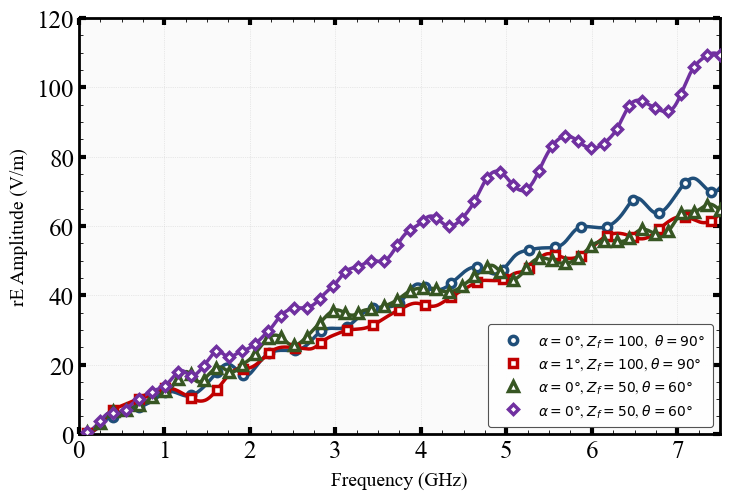

In [52]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── Publication-quality style (OriginPro-like) ───────────────────────────────
rcParams['font.family']         = 'Times New Roman'
rcParams['font.size']           = 18
rcParams['axes.linewidth']      = 2
rcParams['xtick.direction']     = 'in'
rcParams['ytick.direction']     = 'in'
rcParams['xtick.top']           = True
rcParams['ytick.right']         = True
rcParams['xtick.major.size']    = 5
rcParams['ytick.major.size']    = 5
rcParams['xtick.minor.size']    = 3
rcParams['ytick.minor.size']    = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True
rcParams['xtick.major.width']   = 3
rcParams['ytick.major.width']   = 3

# ── 1. LOAD HFSS DATA ────────────────────────────────────────────────────────
S11_1 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE_mag_alpha0_100.csv')
S11_2 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE_alpha1_100.csv')
S11_3 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE_mag_alpha0_50_old.csv')
S11_4 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\rE_mag_alpha0_50.csv')

freq_raw_1 = S11_1['Freq [GHz]'].values * 1e9
freq_raw_2 = S11_2['Freq [GHz]'].values * 1e9
freq_raw_3 = S11_3['Freq [GHz]'].values * 1e9
freq_raw_4 = S11_4['Freq [GHz]'].values * 1e9

mag_raw_1 = S11_1['rETotal [V]'].values
mag_raw_2 = S11_2['rETotal [V]'].values
mag_raw_3 = S11_3['rETotal [V]'].values
mag_raw_4 = S11_4['rETotal [V]'].values

# ── 2. INTERPOLATE onto fine FFT grid ────────────────────────────────────────
interp_mag_1 = CubicSpline(freq_raw_1, mag_raw_1)
interp_mag_2 = CubicSpline(freq_raw_2, mag_raw_2)
interp_mag_3 = CubicSpline(freq_raw_3, mag_raw_3)
interp_mag_4 = CubicSpline(freq_raw_4, mag_raw_4)

f_freq_1 = np.linspace(freq_raw_1[0], freq_raw_1[-1], 2000)
f_freq_2 = np.linspace(freq_raw_2[0], freq_raw_2[-1], 2000)
f_freq_3 = np.linspace(freq_raw_3[0], freq_raw_3[-1], 2000)
f_freq_4 = np.linspace(freq_raw_4[0], freq_raw_4[-1], 2000)

mag_S_1 = interp_mag_1(f_freq_1)
mag_S_2 = interp_mag_2(f_freq_2)
mag_S_3 = interp_mag_3(f_freq_3)
mag_S_4 = interp_mag_4(f_freq_4)

# ── 3. MARKER POSITIONS – evenly spaced, OriginPro style ─────────────────────
n_markers = 50   # adjust to taste: more = denser markers

# ── 4. PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))

# Each dataset: (freq_array, mag_array, color, marker, marker_size, label)
datasets = [
    (f_freq_1, mag_S_1, '#1f4e79', 'o', 6.0,  r'$\alpha = 0°$, $Z_f = 100$,  $\theta = 90°$'),
    (f_freq_2, mag_S_2, '#c00000', 's', 6.0,  r'$\alpha = 1°$, $Z_f = 100$, $\theta = 90°$'),
    (f_freq_3, mag_S_3, '#375623', '^', 6.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
    (f_freq_4, mag_S_4, '#7030a0', 'D', 5.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
]

for fx, my, col, mk, ms, lbl in datasets:
    idx = np.linspace(0, len(fx) - 1, n_markers, dtype=int)

    # Solid line (no marker)
    ax.plot(fx / 1e9, my, color=col, linewidth=2.5, zorder=2)

    # Hollow markers spaced along the line (legend-only label on this handle)
    ax.plot(fx[idx] / 1e9, my[idx],
            marker=mk, color=col, markersize=ms,
            linestyle='none',
            markerfacecolor='white', markeredgewidth=2.5,
            zorder=3, label=lbl)

# ── 5. AXES ───────────────────────────────────────────────────────────────────
ax.set_xlim(0, 7.5)
# Adjust ylim to suit your data; -40 to 0 is typical for S11 in dB
ax.set_ylim(0, 120)

ax.set_xlabel('Frequency (GHz)', fontsize=14, labelpad=6)
ax.set_ylabel(r'rE Amplitude (V/m)',  fontsize=14, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

# Standard −10 dB antenna bandwidth threshold line
# ax.axhline(0, color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=1)
# ax.text(7.42, -8.9, '0 dB', fontsize=9, color='black', ha='right')

# ── 6. LEGEND ─────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=10,
    loc='lower right',        # change to 'upper right' etc. if needed
    frameon=True,
    framealpha=0.92,
    edgecolor='#444444',
    borderpad=0.6,
    handlelength=2.4,
    handletextpad=0.6,
    labelspacing=0.45,
)
leg.get_frame().set_linewidth(0.8)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, color='#cccccc', alpha=0.8)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.8)

# ── 7. SAVE ───────────────────────────────────────────────────────────────────
plt.savefig('rE.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

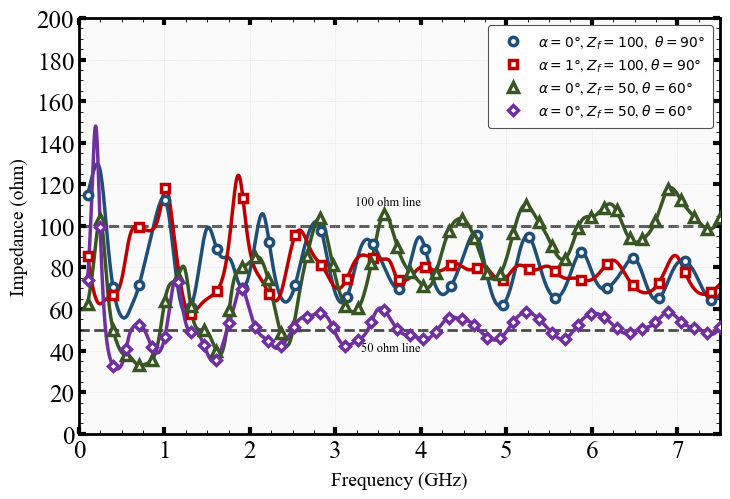

In [51]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── Publication-quality style (OriginPro-like) ───────────────────────────────
rcParams['font.family']         = 'Times New Roman'
rcParams['font.size']           = 18
rcParams['axes.linewidth']      = 2
rcParams['xtick.direction']     = 'in'
rcParams['ytick.direction']     = 'in'
rcParams['xtick.top']           = True
rcParams['ytick.right']         = True
rcParams['xtick.major.size']    = 5
rcParams['ytick.major.size']    = 5
rcParams['xtick.minor.size']    = 3
rcParams['ytick.minor.size']    = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True
rcParams['xtick.major.width']   = 3
rcParams['ytick.major.width']   = 3

# ── 1. LOAD HFSS DATA ────────────────────────────────────────────────────────
S11_1 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\Z_param_alpha0_100.csv')
S11_2 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\Z_param_alpha1_100.csv')
S11_3 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\Z_param_alpha0_50_old.csv')
S11_4 = pd.read_csv(r'C:\Shakthi\Shakthi_HFSS\Z_param_alpha0_50.csv')

freq_raw_1 = S11_1['Freq [GHz]'].values * 1e9
freq_raw_2 = S11_2['Freq [GHz]'].values * 1e9
freq_raw_3 = S11_3['Freq [GHz]'].values * 1e9
freq_raw_4 = S11_4['Freq [GHz]'].values * 1e9

mag_raw_1 = S11_1['re(Z(LumpedPort1,LumpedPort1)) []'].values
mag_raw_2 = S11_2['re(Z(LumpedPort1,LumpedPort1)) []'].values
mag_raw_3 = S11_3['re(Z(LumpedPort1,LumpedPort1)) []'].values
mag_raw_4 = S11_4['re(Z(LumpedPort1,LumpedPort1)) []'].values

# ── 2. INTERPOLATE onto fine FFT grid ────────────────────────────────────────
interp_mag_1 = CubicSpline(freq_raw_1, mag_raw_1)
interp_mag_2 = CubicSpline(freq_raw_2, mag_raw_2)
interp_mag_3 = CubicSpline(freq_raw_3, mag_raw_3)
interp_mag_4 = CubicSpline(freq_raw_4, mag_raw_4)

f_freq_1 = np.linspace(freq_raw_1[0], freq_raw_1[-1], 2000)
f_freq_2 = np.linspace(freq_raw_2[0], freq_raw_2[-1], 2000)
f_freq_3 = np.linspace(freq_raw_3[0], freq_raw_3[-1], 2000)
f_freq_4 = np.linspace(freq_raw_4[0], freq_raw_4[-1], 2000)

mag_S_1 = interp_mag_1(f_freq_1)
mag_S_2 = interp_mag_2(f_freq_2)
mag_S_3 = interp_mag_3(f_freq_3)
mag_S_4 = interp_mag_4(f_freq_4)

# ── 3. MARKER POSITIONS – evenly spaced, OriginPro style ─────────────────────
n_markers = 50   # adjust to taste: more = denser markers

# ── 4. PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))

# Each dataset: (freq_array, mag_array, color, marker, marker_size, label)
datasets = [
    (f_freq_1, mag_S_1, '#1f4e79', 'o', 6.0,  r'$\alpha = 0°$, $Z_f = 100$,  $\theta = 90°$'),
    (f_freq_2, mag_S_2, '#c00000', 's', 6.0,  r'$\alpha = 1°$, $Z_f = 100$, $\theta = 90°$'),
    (f_freq_3, mag_S_3, '#375623', '^', 6.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
    (f_freq_4, mag_S_4, '#7030a0', 'D', 5.5,  r'$\alpha = 0°$, $Z_f = 50$, $\theta = 60°$'),
]

for fx, my, col, mk, ms, lbl in datasets:
    idx = np.linspace(0, len(fx) - 1, n_markers, dtype=int)

    # Solid line (no marker)
    ax.plot(fx / 1e9, my, color=col, linewidth=2.5, zorder=2)

    # Hollow markers spaced along the line (legend-only label on this handle)
    ax.plot(fx[idx] / 1e9, my[idx],
            marker=mk, color=col, markersize=ms,
            linestyle='none',
            markerfacecolor='white', markeredgewidth=2.5,
            zorder=3, label=lbl)

# ── 5. AXES ───────────────────────────────────────────────────────────────────
ax.set_xlim(0, 7.5)
# Adjust ylim to suit your data; -40 to 0 is typical for S11 in dB
ax.set_ylim(0, 200)

ax.set_xlabel('Frequency (GHz)', fontsize=14, labelpad=6)
ax.set_ylabel(r'Impedance (ohm)',  fontsize=14, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

# Standard −10 dB antenna bandwidth threshold line
ax.axhline(100, color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=1)
ax.text(4, 110, '100 ohm line', fontsize=9, color='black', ha='right')

ax.axhline(50, color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=1)
ax.text(4, 40, '50 ohm line', fontsize=9, color='black', ha='right')


# ── 6. LEGEND ─────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=10,
    loc='upper right',        # change to 'upper right' etc. if needed
    frameon=True,
    framealpha=0.92,
    edgecolor='#444444',
    borderpad=0.6,
    handlelength=2.4,
    handletextpad=0.6,
    labelspacing=0.45,
)
leg.get_frame().set_linewidth(0.8)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, color='#cccccc', alpha=0.8)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout(pad=0.8)

# ── 7. SAVE ───────────────────────────────────────────────────────────────────
plt.savefig('impedance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()